# Pixel Visualization

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import cv2

# Load the image
image_path = "star.jpg"  # Replace with your image path
image = Image.open(image_path)
image = image.resize((100, 100))  # Resize for simplicity
image_array = np.array(image)

# Reshape the image into (num_pixels, 3)
pixels = image_array.reshape(-1, 3)  # Assumes the image is in RGB format

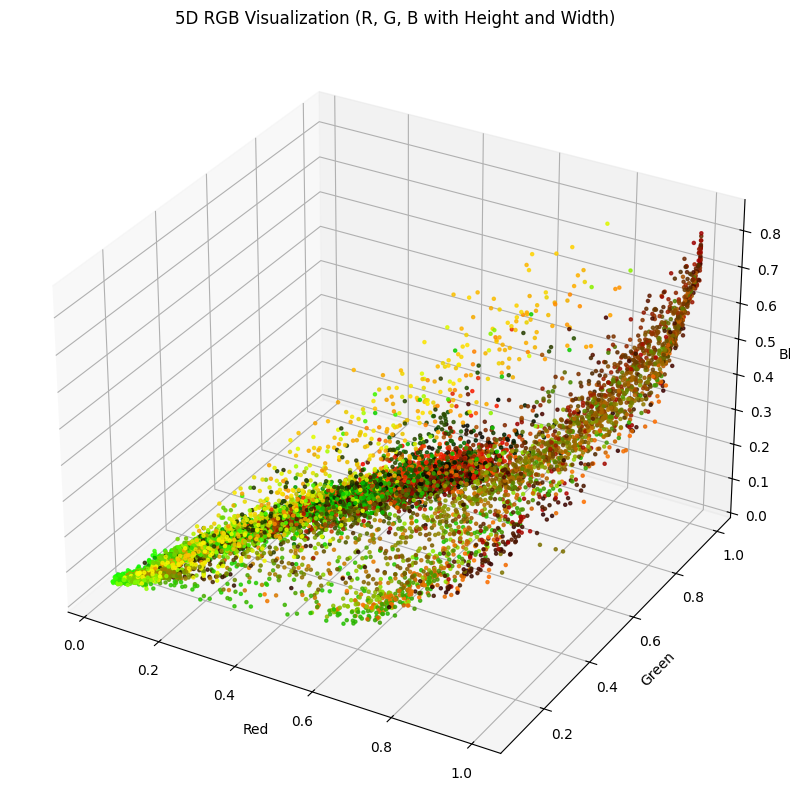

In [15]:
# Get image dimensions
height, width, _ = image_array.shape

# Create a meshgrid for height and width
h, w = np.meshgrid(np.arange(height), np.arange(width))
h = h.flatten()  # Flatten height coordinates
w = w.flatten()  # Flatten width coordinates

# Reshape the image array and extract RGB values
pixels = image_array.reshape(-1, 3)
R, G, B = pixels[:, 0], pixels[:, 1], pixels[:, 2]

# Normalize RGB values to [0, 1] for plotting
R, G, B = R / 255.0, G / 255.0, B / 255.0

# Create the 3D scatter plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot using R, G, B as positions and (h, w) as color
scatter = ax.scatter(R, G, B, c=np.stack([h, w, np.zeros_like(h)]).T / max(h.max(), w.max()), 
                     s=5, marker='o', alpha=0.8)

# Labels and title
ax.set_xlabel("Red")
ax.set_ylabel("Green")
ax.set_zlabel("Blue")
ax.set_title("5D RGB Visualization (R, G, B with Height and Width)")
plt.show()

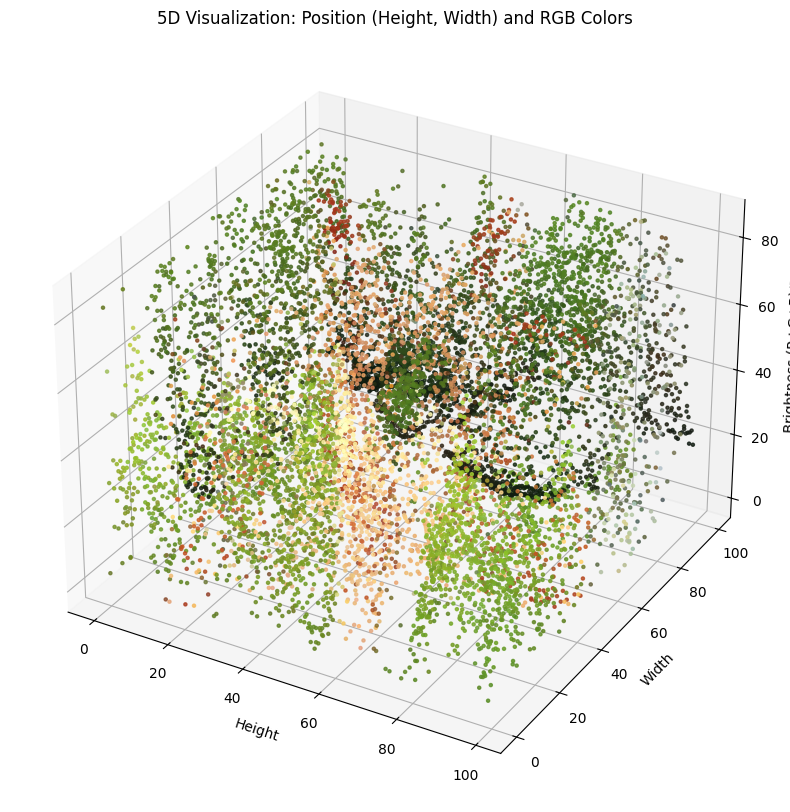

In [16]:
colors = pixels / 255.0 

# Extract RGB channels
R, G, B = pixels[:, 0], pixels[:, 1], pixels[:, 2]

# Create 3D scatter plot: Height (y), Width (x), and Brightness (e.g., sum of RGB)
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with height, width, and brightness
brightness = (R + G + B) / 3.0  # Example dimension for z-axis (you can change this)
scatter = ax.scatter(h, w, brightness, c=colors, s=5, marker='o', alpha=0.8)

# Labels and title
ax.set_xlabel("Height")
ax.set_ylabel("Width")
ax.set_zlabel("Brightness (R+G+B)/3")
ax.set_title("5D Visualization: Position (Height, Width) and RGB Colors")

plt.show()

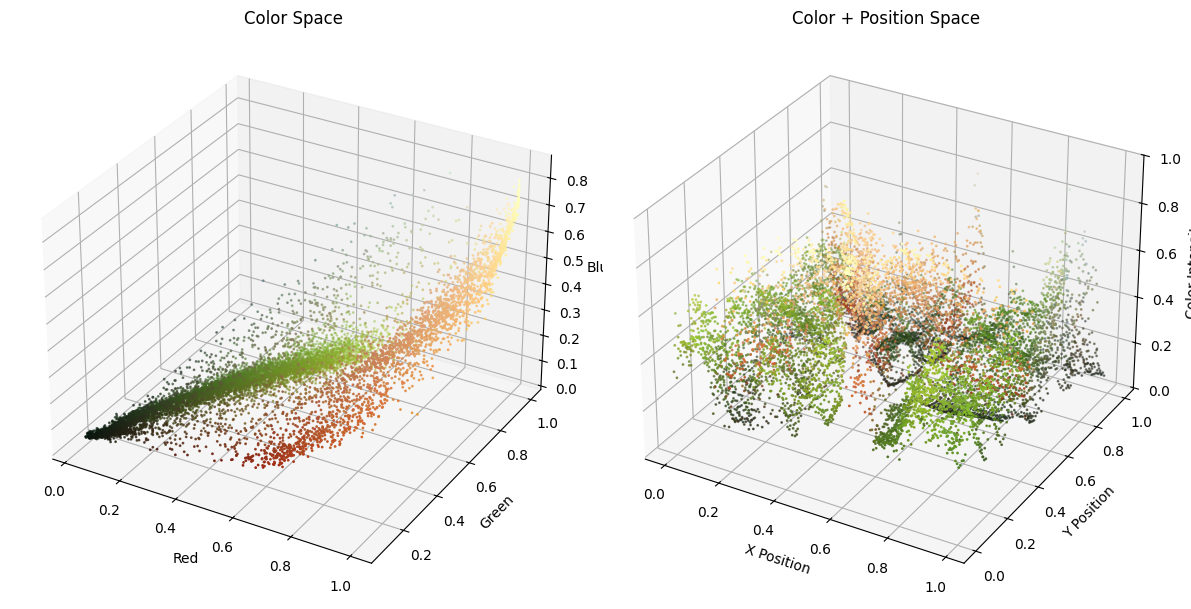

In [8]:
pixels = np.array(image)

# Step 2: Extract RGB values and spatial positions
h, w, _ = pixels.shape
r = pixels[:, :, 0].flatten() / 255.0  # Normalize RGB values to [0, 1]
g = pixels[:, :, 1].flatten() / 255.0
b = pixels[:, :, 2].flatten() / 255.0

x, y = np.meshgrid(range(w), range(h))  # Create X, Y coordinates
x = x.flatten() / w  # Normalize spatial positions to [0, 1]
y = y.flatten() / h

# Step 3: Combine RGB and spatial positions
color_space = np.vstack((r, g, b)).T
color_position_space = np.vstack((r, g, b, x, y)).T

# Step 4: Visualize
fig = plt.figure(figsize=(12, 6))

# Plot "Color Space"
ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(r, g, b, c=color_space, s=1)
ax1.set_title("Color Space")
ax1.set_xlabel("Red")
ax1.set_ylabel("Green")
ax1.set_zlabel("Blue")

# Plot "Color + Position Space"
ax2 = fig.add_subplot(122, projection="3d")
color_intensity = (r + g + b) / 3  # Average color intensity
ax2.scatter(x, y, color_intensity, c=color_space, s=1)
ax2.set_title("Color + Position Space")
ax2.set_xlabel("X Position")
ax2.set_ylabel("Y Position")
ax2.set_zlabel("Color Intensity")

plt.tight_layout()
plt.show()

# K-Mean

In [94]:
def initialize_centroids(X, k):
    indices = np.random.choice(X.shape[0], k, replace=False)
    return X[indices]

def compute_distances(X, centroids):
    distances = np.zeros((X.shape[0], len(centroids)))
    for i, centroid in enumerate(centroids):
        distances[:, i] = np.linalg.norm(X - centroid, axis=1)
    return distances

def assign_clusters(distances):
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k):
    centroids = np.zeros((k, X.shape[1]))
    for i in range(k):
        points_in_cluster = X[labels == i]
        if points_in_cluster.size > 0:
            centroids[i] = points_in_cluster.mean(axis=0)
    return centroids

def kmeans(X, k, max_iters=100, tol=1e-4):
    centroids = initialize_centroids(X, k)
    for _ in range(max_iters):
        old_centroids = centroids
        distances = compute_distances(X, centroids)
        labels = assign_clusters(distances)
        centroids = update_centroids(X, labels, k)

        if np.linalg.norm(centroids - old_centroids) < tol:
            break
        
    return labels, centroids

In [95]:
image = cv2.imread('star.jpg')
 
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

pixel_vals = image.reshape((-1,3))
 
# Convert to float type
pixel_vals = np.float32(pixel_vals)

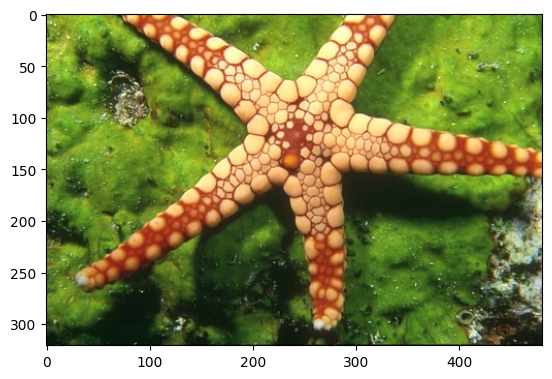

In [75]:
plt.imshow(image)

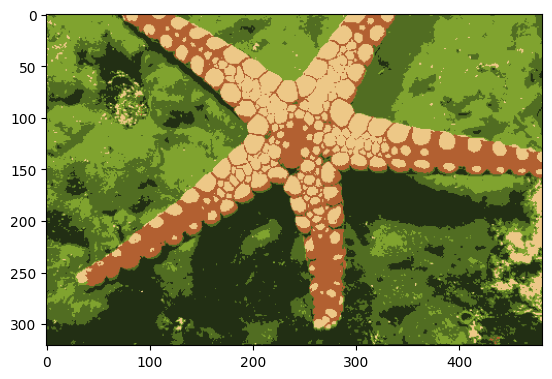

In [111]:
k = 5

labels, centroids = kmeans(pixel_vals, k)

centers = np.uint8(centroids)
segmented_data = centers[labels.flatten()]
 
segmented_image = segmented_data.reshape((image.shape))
 
plt.imshow(segmented_image)

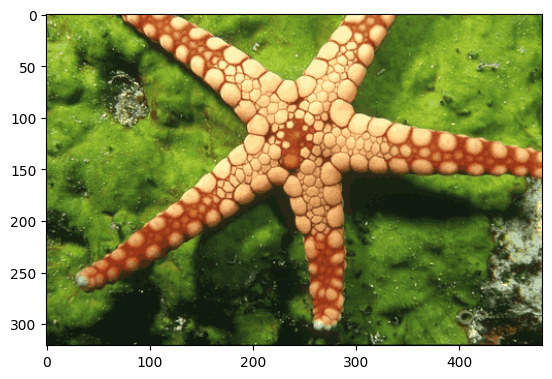

In [110]:
k = 50

labels, centroids = kmeans(pixel_vals, k)

centers = np.uint8(centroids)
segmented_data = centers[labels.flatten()]
 
segmented_image = segmented_data.reshape((image.shape))
 
plt.imshow(segmented_image)